In [1]:
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from src.utils import align_tracked_particle_across_layers
from src.jax_resnet.model import init_params

In [3]:
from exp_config import (
    d_in, d_out, seed, N, X_train, Y_train, X_test, Y_test, 
    tau, n_steps, lr_in, lr_out, q, batch_size, 
    last_particle_single_source, eval_every, ACTIVATION, num_repetitions, LOOP_SEED,
    BASE_SETTING_STR
    )

(8000, 784) (8000, 2) (2000, 784) (2000, 2)


In [4]:
D, L, M = 10, 1024, 1024

In [5]:
params0 = init_params(random.PRNGKey(seed + 44), d_in, d_out, D, L, M)
params0 = align_tracked_particle_across_layers(params0, particle_idx=-1)

In [6]:
import pickle

setting_str = f'L{L}_M{M}_D{D}' + BASE_SETTING_STR


with open(f'data/mnist/histories_gd_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_gd = pickle.load(f)
with open(f'data/mnist/histories_do_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_do = pickle.load(f)
with open(f'data/mnist/histories_ram_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_ram = pickle.load(f)


In [7]:
# Compare test loss across GD, Dropout and RaM for selected variants

def plot_test_loss_compare_all_runs(show=True, xlim=None, ylim=None, eval_every=10, n_steps=None):
    """Plot mean ± std of test loss over iterations for GD, full_unit, and stochastic_depth runs."""
    run_specs = {
        'GD': histories_gd["gd"],
        'Dropout (full-unit)': histories_do["full_unit_dropout"],
        'RaM (full-unit)': histories_ram["full_unit_dropout"],
        'Dropout (stochastic depth)': histories_do["stochastic_depth"],
        'RaM (stochastic depth)': histories_ram["stochastic_depth"],
        'Dropout (depth shared)': histories_do["single_source_M"],
        'RaM (depth shared)': histories_ram["single_source_M"],
    }
    run_colors = {
        'GD': 'black',
        'Dropout (full-unit)': 'tab:blue',
        'RaM (full-unit)': 'tab:blue',
        'Dropout (stochastic depth)': 'tab:green',
        'RaM (stochastic depth)': 'tab:green',
        'Dropout (depth shared)': 'tab:purple',
        'RaM (depth shared)': 'tab:purple',
    }
    run_linestyles = {
        'GD': '-',
        'Dropout (full-unit)': '--',
        'RaM (full-unit)': '-',
        'Dropout (stochastic depth)': '--',
        'RaM (stochastic depth)': '-',
        'Dropout (depth shared)': '--',
        'RaM (depth shared)': '-',
    }

    # number of recorded evaluation points (checkpoints) in histories
    num_points = len(histories_gd["gd"][0]['test_loss'])
    # index of recorded checkpoints (0..num_points-1)
    idx = np.arange(num_points)
    # map checkpoint indices to actual training steps: normally idx * eval_every
    x_steps = idx * eval_every
    # if n_steps not provided, try to pick it from the notebook globals (common in this notebook)
    if n_steps is None:
        n_steps_local = globals().get('n_steps', None)
    else:
        n_steps_local = n_steps
    # ensure final recorded point corresponds to final training step (n_steps-1) when applicable
    if n_steps_local is not None:
        # if the final checkpoint isn't exactly (n_steps-1) because of eval_every spacing,
        # set the last x value to n_steps-1 to reflect the actual final step recorded
        if x_steps[-1] != (n_steps_local - 1):
            x_steps[-1] = n_steps_local - 1

    fig, ax = plt.subplots(figsize=(6, 4))

    for run_name, run_history in run_specs.items():
        values = np.stack([np.asarray(h['test_loss']) for h in run_history], axis=0)
        mean = values.mean(axis=0)
        std = values.std(axis=0)
        color = run_colors[run_name]
        linestyle = run_linestyles[run_name]
        ax.plot(x_steps, mean, label=run_name, color=color, linestyle=linestyle)
        ax.fill_between(x_steps, mean - std, mean + std, color=color, alpha=0.15)

    #ax.set_yscale('log')
    ax.set_title('Test loss comparison')
    ax.set_xlabel('training step')
    ax.set_ylabel('test loss')
    
    # Handle xlim: allow None values to mean "use computed limits"
    if xlim is not None:
        left, right = xlim[0] if len(xlim) > 0 else None, xlim[1] if len(xlim) > 1 else None
        if left is None:
            left = x_steps[0]
        if right is None:
            right = x_steps[-1]
        ax.set_xlim(left, right)
    else:
        left, right = x_steps[0], x_steps[-1]
        # set reasonable x-limits from the computed training-step checkpoints
        ax.set_xlim(left, right)
    
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(fontsize=6)

    # set tick frequency to show at most ~10 ticks, but only from visible range
    try:
        # Filter x_steps to only those within the xlim range
        visible_steps = x_steps[(x_steps >= left) & (x_steps <= right)]
        n_ticks = min(10, len(visible_steps))
        if n_ticks > 1 and len(visible_steps) > 0:
            step = max(1, len(visible_steps) // n_ticks)
            ax.set_xticks(visible_steps[::step])
    except Exception:
        pass

    fig.tight_layout()
    if show:
        plt.show()
    return fig

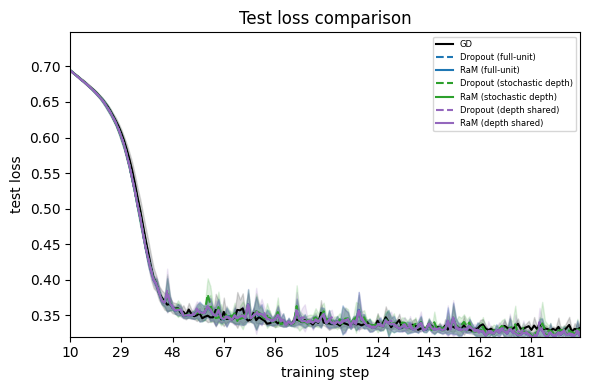

In [8]:
fig = plot_test_loss_compare_all_runs(xlim=(10, None), ylim=(0.32,None), eval_every=eval_every, n_steps=n_steps)

In [9]:
#fig.savefig(f"plots/mnist_loss_ram_do_all_variants_N{N}_datasetL{L}M{M}.pdf")